# MMT-03 Resource Addendum - Market Landscape And Algorithm Taxonomy

This additive notebook covers official lecture-note items that sit around the existing cost/routing examples: market participants, algorithm families, execution style, dynamic updating, and intraday microstructure profiles.

## Setup

Load the reference tables created from the lecture summary and lecture note.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
print("setup complete")

setup complete


## Financial market participants

The execution decision is made inside a broader ecosystem: institutions generate large orders, brokers facilitate execution, venues host liquidity, and liquidity/HFT firms often supply or remove displayed liquidity.

In [2]:
participants = pd.read_csv("mmt03_market_participants.csv")
display(participants)

,participant,primary_role,typical_motivation,examples
0,Brokers,facilitate client execution,"commissions, principal bid premium, client ser...","investment banks, full-service, bulge bracket,..."
1,Institutions,invest and rebalance portfolios,implementation consistent with fund objective,"asset managers, mutual funds, index funds, ins..."
2,Hedge funds,seek alpha and manage risk,quant and non-quant investment profits,"long/short, statistical arbitrage, event strat..."
3,Liquidity providers,post bids and asks,spread capture and venue rebates,"specialists, market makers, NYSE DMM, Nasdaq Q..."
4,Retail investors,individual trading and investing,"portfolio allocation, wealth management, specu...","individuals, wealth managers, Gen-X, millennia..."
5,Proprietary trading firms,trade firm capital,short-horizon trading profit,"prop firms, market-making firms"
6,High-frequency traders,fast liquidity and pattern trading,"spread, rebates, short-term order-flow patterns",HFT liquidity and rebate strategies


## Algorithm families

MMT-03 distinguishes execution-only algorithms from profit-seeking algorithms, market-making/HFT logic, liquidity-seeking logic, and direct market access.

In [3]:
taxonomy = pd.read_csv("mmt03_algorithm_taxonomy.csv")
display(taxonomy)

,family,decision_scope,typical_user,key_controls
0,Execution-only,execute an order already decided by the portfo...,institutional buy side,"schedule, urgency, limit/market mix, venue rou..."
1,Quant / profit-seeking,decide the investment and execute it,"quant funds, prop firms","signal model, risk limits, immediate execution..."
2,Auto market making / HFT,post bids and asks to provide liquidity,"market makers, HFT firms","spread, inventory, rebates, adverse selection"
3,Liquidity trading,find and capture available liquidity,HFT and broker liquidity algos,"venue mix, displayed/dark split, pattern detec..."
4,Direct market access,client uses broker connectivity with own logic,sophisticated institutions,"connectivity, risk checks, venue access"


## Urgency, static updates, and dynamic updates

Urgency describes how aggressively the algorithm should trade; updating describes whether the algorithm can revise itself without a manual trader change.

In [4]:
strategy = pd.read_csv("mmt03_strategy_classification.csv")
display(strategy)

,classification,definition,order_mix,examples
0,Aggressive,get me done; sweep all liquidity at my price o...,more market orders,"urgent sweep, completion trade"
1,Working order,balance market impact and timing risk,market and limit orders,"VWAP, TWAP, POV, IS, optimal strategy"
2,Passive,"use crossing systems and dark pools, wait for ...",more limit orders,"liquidity seeking, dark-pool posting"
3,Static,parameters do not change unless the trader rev...,fixed by initial setup,"fixed TWAP, fixed POV"
4,Dynamic,algorithm revises rate/parameters from live ma...,"changes with prices, volume, and optimization","dynamic POV, arrival price, re-optimized schedule"


## Intraday microstructure profiles

The transcript emphasizes that intraday volume is now more J-shaped, volatility is closer to L-shaped, and spreads are widest near the open/close. Execution algorithms use these shapes when deciding schedule, limit prices, and routing urgency.

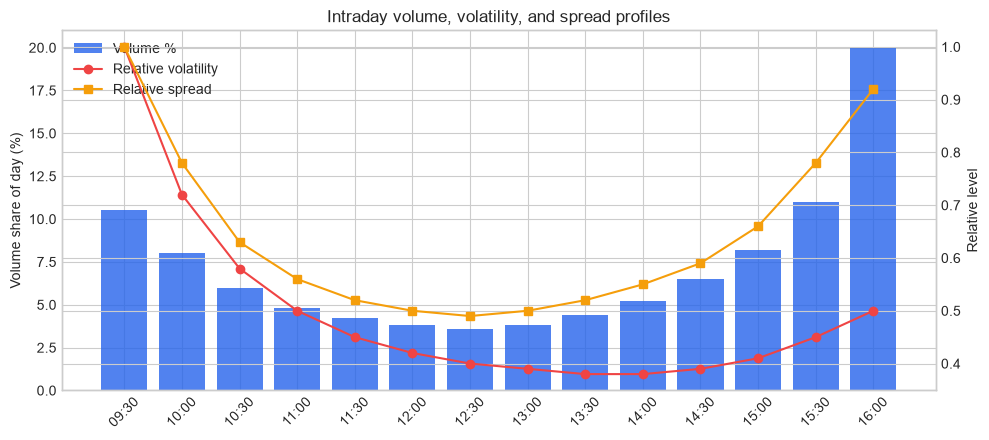

In [5]:
profiles = pd.read_csv("mmt03_intraday_profiles.csv")
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(profiles["bucket"], profiles["volume_pct"], color="#2563eb", alpha=0.8, label="Volume %")
ax1.set_ylabel("Volume share of day (%)")
ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx()
ax2.plot(profiles["bucket"], profiles["relative_volatility"], color="#ef4444", marker="o", label="Relative volatility")
ax2.plot(profiles["bucket"], profiles["relative_spread"], color="#f59e0b", marker="s", label="Relative spread")
ax2.set_ylabel("Relative level")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.title("Intraday volume, volatility, and spread profiles")
plt.tight_layout()
plt.show()

## Broker execution style

Agency and principal bid decisions are not only a one-trade expected value problem. The lecture stresses frequency: a 70% chance of agency beating the principal bid is very different for daily trading than for one annual trade.

In [6]:
styles = pd.read_csv("mmt03_execution_styles.csv")
display(styles)

,style,who_bears_risk,broker_compensation,price_certainty
0,Agency execution,investor,"commission, often 1-3 cents/share",unknown until execution completes
1,Principal bid / capital commitment,broker after committing price,"premium, often much higher such as 5-25 cents/...",guaranteed benchmark or all-in price


## Algorithmic decision process

The implementation process links the macro schedule to the micro order-placement problem.

In [7]:
decision = pd.read_csv("mmt03_decision_process.csv")
display(decision)

,step,process_step,question
0,1,Select broker,"Who can execute with the required quality, ven..."
1,2,Select algorithm and parameters,"What schedule, risk aversion, urgency, and ben..."
2,3,Transact using LOM and SOR,What market/limit mix and venue allocation bes...
3,4,Revise if necessary,"Do live prices, volumes, fills, or risk requir..."
4,5,Measure cost and evaluate performance,Did the broker/algorithm deliver quality relat...
